In [2]:
import os
import stat
import subprocess
import json
import ast
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [12]:
def modify_argos_file(argos_file, fsm_config, random_seed):
    """Modify the .argos XML file to update the FSM configuration."""
    tree = ET.parse(argos_file)
    root = tree.getroot()
    
    for params in root.findall(".//params"):
        params.set("fsm-config", fsm_config)

    for experiment in root.findall(".//experiment"):
        experiment.set("random_seed", str(100+random_seed))

    xml_declaration = "<?xml version='1.0' ?>\n"
    modified_content = xml_declaration + ET.tostring(root, encoding='unicode')
    
    with open(argos_file, "w") as f:
        f.write(modified_content)

def run_argos(argos_file):
    """Run ARGoS simulation with the given configuration."""
    script_path = "./argos.sh"
    with open(script_path, 'w+') as f:
        f.write("#!/bin/bash\n")
        f.write("source /home/robotmaster/argos3-installation/habanero/argos3-dist/bin/setup_argos3\n")
        f.write(f"argos3 -c {argos_file}\n")
    
    st = os.stat(script_path)
    os.chmod(script_path, st.st_mode | stat.S_IEXEC)
    
    subprocess.run(["bash", script_path], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def read_score(file_path):
    """Read the score from the score.txt file."""
    data_score = []
    try:
        with open(file_path, 'r') as f:
            for score in f.readlines(): 
                data_score.append(ast.literal_eval(score[:-1]))
            return data_score
    except FileNotFoundError:
        return None
    
def clean_previous_data():
    with open("/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_aggregation.txt", "w") as file:
        pass 
    with open("/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_homing.txt", "w") as file:
        pass 
    with open("/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_tasking.txt", "w") as file:
        pass 

def plot_boxplots(data, plot_title, number_plots, plots_ticks = []):
    plt.boxplot(data, notch=True)
    plt.ticklabel_format(style='plain', axis='y', scilimits=(0,0))
    plt.title(plot_title, fontsize=20, family='sans-serif', pad=30)
    plt.xticks(np.arange(1, number_plots + 1),plots_ticks, fontsize=15)
    plt.yticks(fontsize=15)

def run_experiments(argos_file,score_file, mission_name, n_experiments):
    """Main function to automate the FSM testing process."""

    with open("missions.json", "r") as f:
        fsm_configs = json.load(f)

    n = 0

    clean_previous_data()
 

    for fsm_config in fsm_configs["missions"][0][mission_name]:
        print(f"Running simulation for {mission_name}, fsm {n}...")
        modify_argos_file(argos_file, fsm_config, random_seed=int(n))

        # run experiments
        for _ in range(n_experiments):
            run_argos(argos_file)

        n += 1
        # Save data
    
    return read_score(score_file)



## Homing 

In [4]:
score_dict = {}

In [18]:
# Recuerda configurar una misma random seed, estaba la 102 
# Como voy a hacer el commit para el cluster lo dejaré en aleatorio 
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/hm-20.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_homing.txt"
mission_name = "hm-020"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict[mission_name] = score

Running simulation for hm-020, fsm 0...
Running simulation for hm-020, fsm 1...
Running simulation for hm-020, fsm 2...
Running simulation for hm-020, fsm 3...
Running simulation for hm-020, fsm 4...
Running simulation for hm-020, fsm 5...
Running simulation for hm-020, fsm 6...
Running simulation for hm-020, fsm 7...
Running simulation for hm-020, fsm 8...
Running simulation for hm-020, fsm 9...


In [19]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/hm-40.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_homing.txt"
mission_name = "hm-040"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict[mission_name] = score


Running simulation for hm-040, fsm 0...
Running simulation for hm-040, fsm 1...
Running simulation for hm-040, fsm 2...
Running simulation for hm-040, fsm 3...
Running simulation for hm-040, fsm 4...
Running simulation for hm-040, fsm 5...
Running simulation for hm-040, fsm 6...
Running simulation for hm-040, fsm 7...
Running simulation for hm-040, fsm 8...
Running simulation for hm-040, fsm 9...


In [20]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/hm-60.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_homing.txt"
mission_name = "hm-060"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict[mission_name] = score


Running simulation for hm-060, fsm 0...
Running simulation for hm-060, fsm 1...
Running simulation for hm-060, fsm 2...
Running simulation for hm-060, fsm 3...
Running simulation for hm-060, fsm 4...
Running simulation for hm-060, fsm 5...
Running simulation for hm-060, fsm 6...
Running simulation for hm-060, fsm 7...
Running simulation for hm-060, fsm 8...
Running simulation for hm-060, fsm 9...


In [21]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/hm-80.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_homing.txt"
mission_name = "hm-080"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict[mission_name] = score


Running simulation for hm-080, fsm 0...
Running simulation for hm-080, fsm 1...
Running simulation for hm-080, fsm 2...
Running simulation for hm-080, fsm 3...
Running simulation for hm-080, fsm 4...
Running simulation for hm-080, fsm 5...
Running simulation for hm-080, fsm 6...
Running simulation for hm-080, fsm 7...
Running simulation for hm-080, fsm 8...
Running simulation for hm-080, fsm 9...


In [22]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/hm-100.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_homing.txt"
mission_name = "hm-100"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict[mission_name] = score


Running simulation for hm-100, fsm 0...
Running simulation for hm-100, fsm 1...
Running simulation for hm-100, fsm 2...
Running simulation for hm-100, fsm 3...
Running simulation for hm-100, fsm 4...
Running simulation for hm-100, fsm 5...
Running simulation for hm-100, fsm 6...
Running simulation for hm-100, fsm 7...
Running simulation for hm-100, fsm 8...
Running simulation for hm-100, fsm 9...


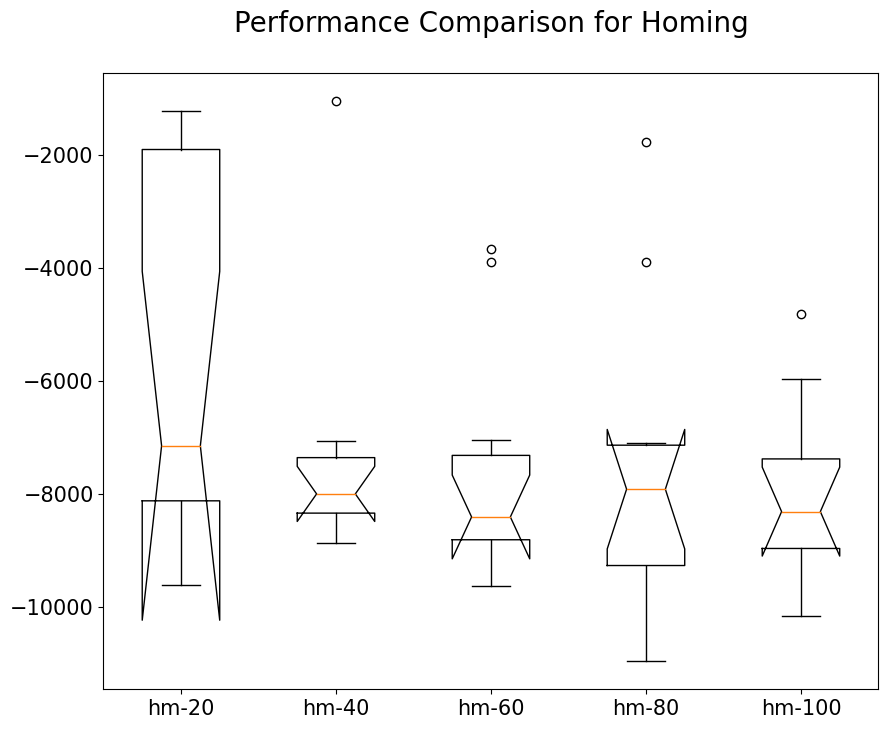

In [ ]:
plt.figure(figsize=(10, 8)) 
plot_boxplots([score for score in score_dict.values()], 'Performance Comparison for Homing (2 leds)', number_plots=len(score_dict), plots_ticks=[f'hm-{i}' for i in [20,40,60,80,100]])


## Tasking

In [39]:
score_dict_tasking = {}

In [40]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/ts-020.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_tasking.txt"
mission_name = "ts-020"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict_tasking[mission_name] = score

Running simulation for ts-020, fsm 0...
Running simulation for ts-020, fsm 1...
Running simulation for ts-020, fsm 2...
Running simulation for ts-020, fsm 3...
Running simulation for ts-020, fsm 4...
Running simulation for ts-020, fsm 5...
Running simulation for ts-020, fsm 6...
Running simulation for ts-020, fsm 7...
Running simulation for ts-020, fsm 8...
Running simulation for ts-020, fsm 9...


In [41]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/ts-040.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_tasking.txt"
mission_name = "ts-040"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict_tasking[mission_name] = score

Running simulation for ts-040, fsm 0...
Running simulation for ts-040, fsm 1...
Running simulation for ts-040, fsm 2...
Running simulation for ts-040, fsm 3...
Running simulation for ts-040, fsm 4...
Running simulation for ts-040, fsm 5...
Running simulation for ts-040, fsm 6...
Running simulation for ts-040, fsm 7...
Running simulation for ts-040, fsm 8...
Running simulation for ts-040, fsm 9...


In [45]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/ts-080.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_tasking.txt"
mission_name = "ts-080"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict_tasking[mission_name] = score

Running simulation for ts-080, fsm 0...
Running simulation for ts-080, fsm 1...
Running simulation for ts-080, fsm 2...
Running simulation for ts-080, fsm 3...
Running simulation for ts-080, fsm 4...
Running simulation for ts-080, fsm 5...
Running simulation for ts-080, fsm 6...
Running simulation for ts-080, fsm 7...
Running simulation for ts-080, fsm 8...
Running simulation for ts-080, fsm 9...


In [53]:
argos_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/scenarios/communication/ts-100.argos"
score_file = "/home/robotmaster/argos3-installation/habanero/habanero-loopfunctions/data/score_tasking.txt"
mission_name = "ts-100"
n_experiments = 1

score = run_experiments(argos_file, score_file, mission_name, n_experiments)
score_dict_tasking[mission_name] = score

Running simulation for ts-100, fsm 0...
Running simulation for ts-100, fsm 1...
Running simulation for ts-100, fsm 2...
Running simulation for ts-100, fsm 3...
Running simulation for ts-100, fsm 4...
Running simulation for ts-100, fsm 5...
Running simulation for ts-100, fsm 6...
Running simulation for ts-100, fsm 7...
Running simulation for ts-100, fsm 8...
Running simulation for ts-100, fsm 9...


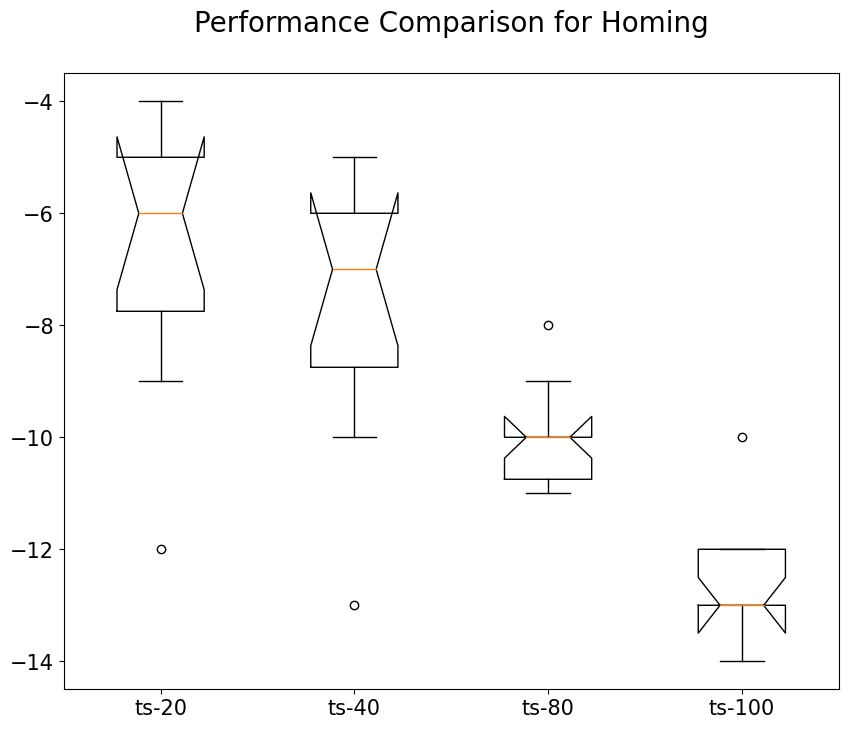

In [54]:
plt.figure(figsize=(10, 8)) 
plot_boxplots([score for score in score_dict_tasking.values()], 'Performance Comparison for Homing', number_plots=len(score_dict_tasking), plots_ticks=[f'ts-{i}' for i in [20,40,80,100]])
